<a href="https://colab.research.google.com/github/risnariha/-Multivariate-Time-Series-Prediction-Model/blob/main/Energy_Prediction_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[]


In [73]:
!pip install tensorflow scikit-learn seaborn matplotlib pandas numpy

In [144]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Input,
    GRU,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

optimizer = Adam(
    learning_rate=0.0005
)

In [75]:
# 1 Data Understanding and Preprocessing

In [76]:
df = pd.read_csv("energy_data_set.csv")

In [77]:
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [78]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


In [79]:
df['date'] = pd.to_datetime(df['date'])

In [80]:
df = df.sort_values('date')

In [81]:
df = df.sort_values('date')

In [82]:
#Check Missing Values

df.isnull().sum()

,0
date,0
Appliances,0
lights,0
T1,0
RH_1,0
T2,0
RH_2,0
T3,0
RH_3,0
T4,0


In [83]:
#Handle Missing Values

df = df.interpolate()

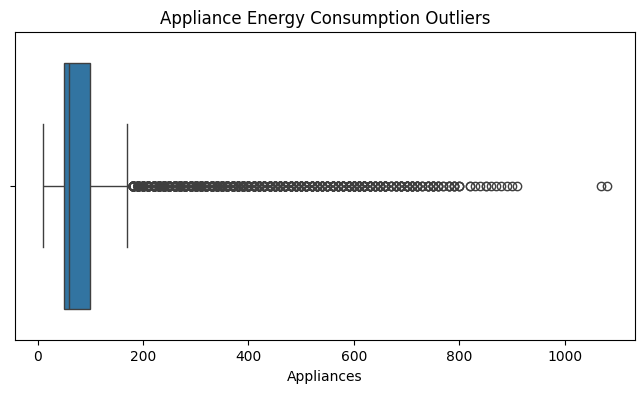

In [84]:
# Outlier Detection

plt.figure(figsize=(8,4))

sns.boxplot(x=df['Appliances'])

plt.title("Appliance Energy Consumption Outliers")

plt.show()

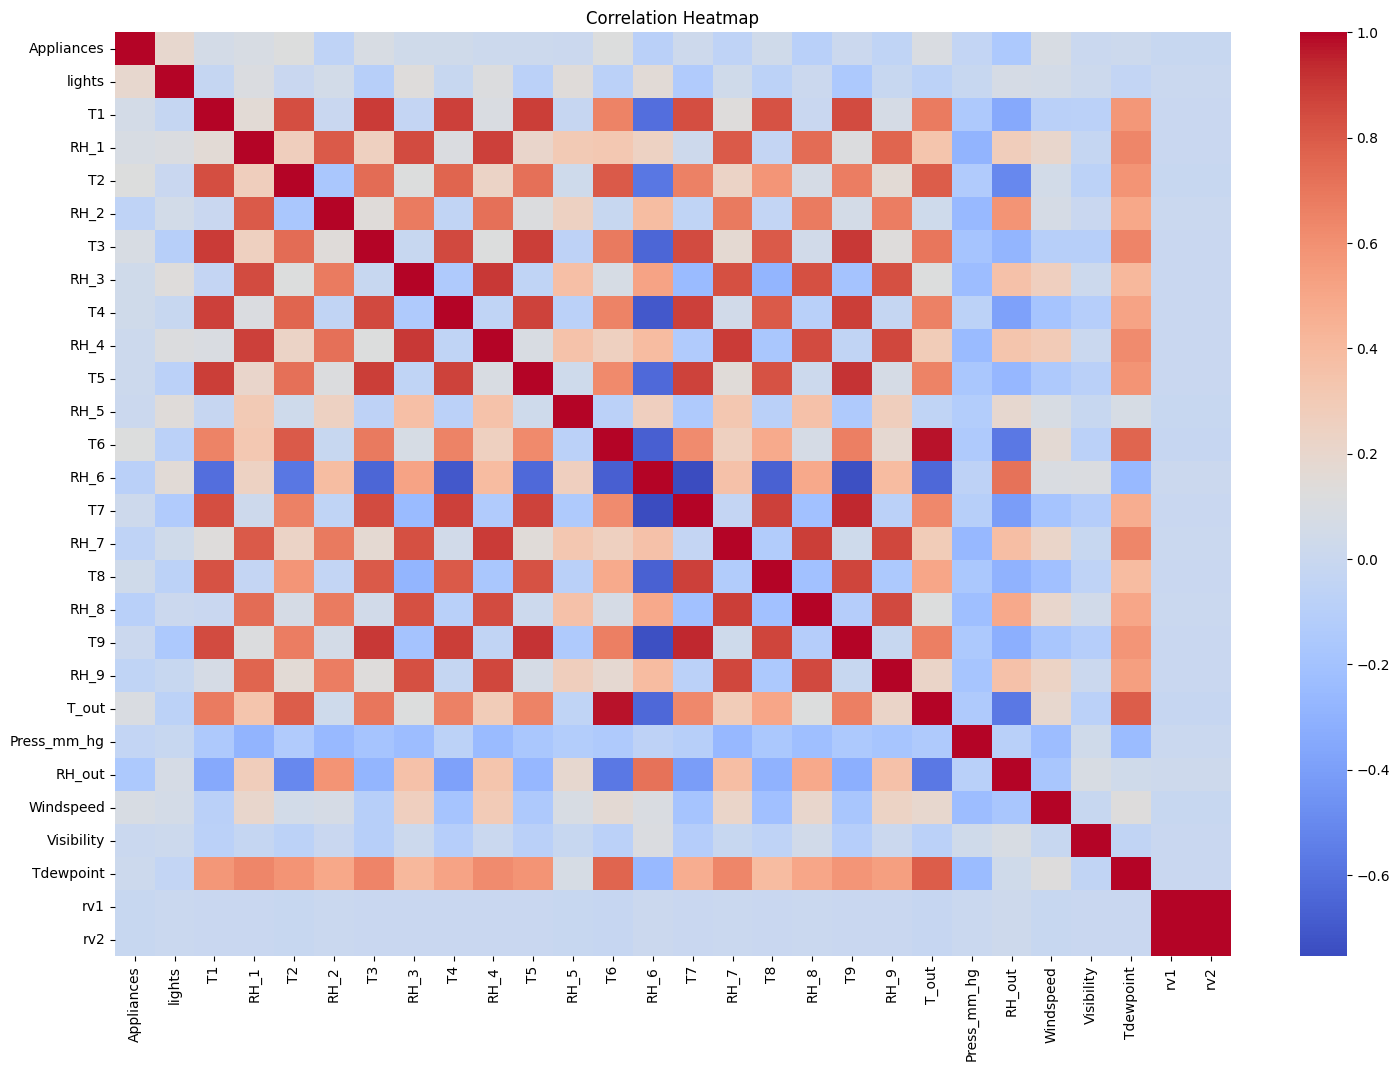

In [85]:
#HEATMAP (correlation)
plt.figure(figsize=(18,12))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [86]:
#weekday vs weekend analysis

df['day_of_week'] = df['date'].dt.dayofweek

df['weekend'] = (
    df['day_of_week']
    .isin([5,6])
    .astype(int)
)

In [87]:
# EXPLORATORY DATA ANALYSIS (EDA)

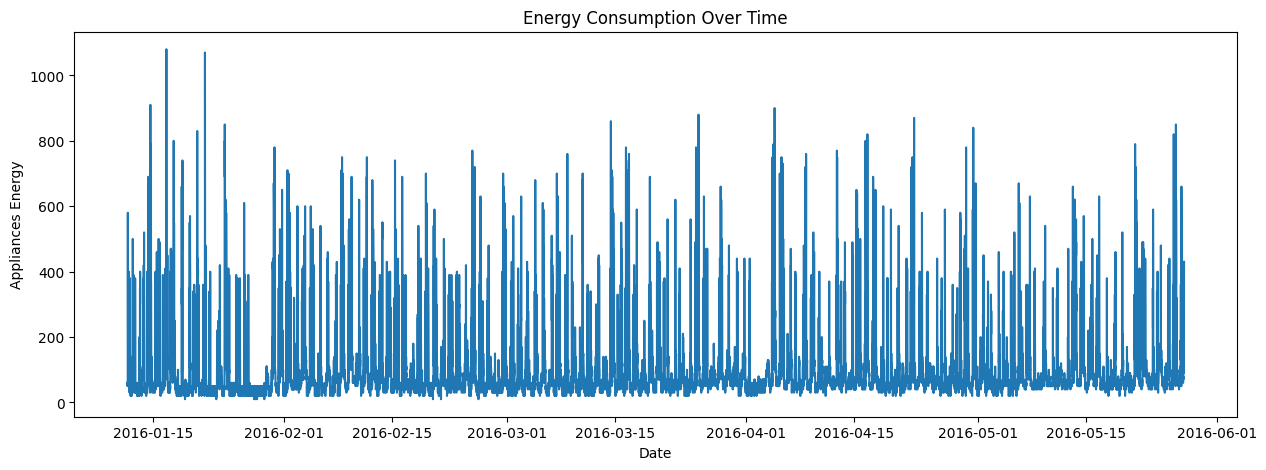

In [88]:
# Energy Consumption Over Time
plt.figure(figsize=(15,5))

plt.plot(df['date'], df['Appliances'])

plt.title("Energy Consumption Over Time")

plt.xlabel("Date")
plt.ylabel("Appliances Energy")

plt.show()

In [89]:
# 2 FEATURE ENGINEERING

In [90]:
#created hour feature
df['hour'] = df['date'].dt.hour

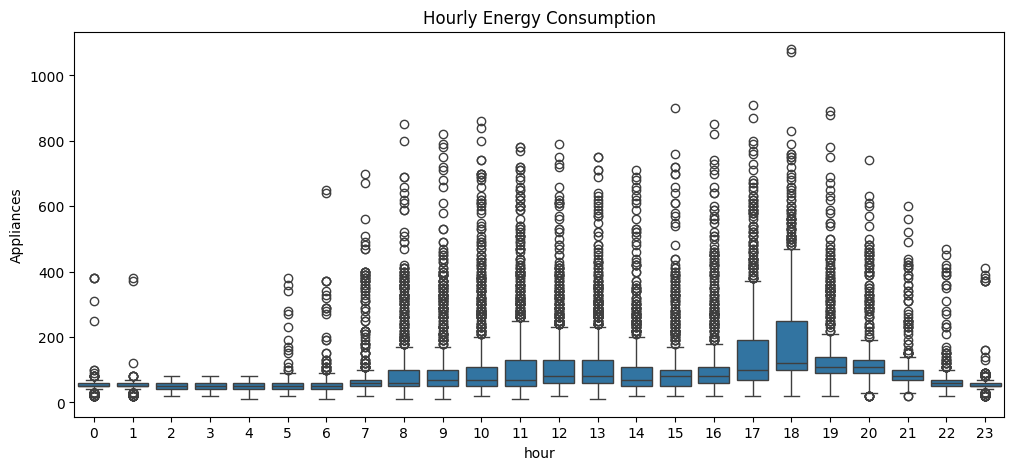

In [91]:
plt.figure(figsize=(12,5))

sns.boxplot(
    x='hour',
    y='Appliances',
    data=df
)

plt.title("Hourly Energy Consumption")

plt.show()

In [92]:
#created time feature
df['month'] = df['date'].dt.month

df['day'] = df['date'].dt.day

df['minute'] = df['date'].dt.minute

In [339]:
#Lag and Rolling features


df['lag_1'] = df['Appliances'].shift(1)

df['lag_6'] = df['Appliances'].shift(6)

df['lag_12'] = df['Appliances'].shift(12)

df['lag_24'] = df['Appliances'].shift(24)

df['rolling_mean_12'] = (
    df['Appliances']
    .rolling(12)
    .mean()
)

df['rolling_mean_24'] = (
    df['Appliances']
    .rolling(24)
    .mean()
)

df['rolling_std_24'] = (
    df['Appliances']
    .rolling(24)
    .std()
)

In [340]:
df = df.dropna()

In [262]:
#created Interaction Features

df['temp_humidity'] = (
    df['T1'] * df['RH_1']
)

In [328]:
df = df.dropna()

In [97]:
# FEATURE SELECTION

In [329]:
correlation = (
    df.corr(numeric_only=True)['Appliances']
    .sort_values(ascending=False)
)

print(correlation)

Appliances         1.000000
lag_1              0.753117
rolling_mean_12    0.635960
rolling_std_24     0.551705
rolling_mean_24    0.518744
lag_6              0.325871
lag_12             0.312371
hour               0.216641
lights             0.196120
T2                 0.120083
T6                 0.117924
lag_24             0.114976
T_out              0.099407
temp_humidity      0.094562
Windspeed          0.086794
RH_1               0.086655
T3                 0.085748
T1                 0.055293
T4                 0.040681
T8                 0.040303
RH_3               0.036354
T7                 0.026199
T5                 0.020038
weekend            0.017615
RH_4               0.016477
Tdewpoint          0.015353
minute             0.013351
T9                 0.010412
RH_5               0.006356
day_of_week        0.003674
day                0.002558
Visibility         0.000069
rv2               -0.010689
rv1               -0.010689
month             -0.011417
Press_mm_hg       -0

In [341]:
#Select Features
selected_features = [

    'lag_1',
    'rolling_mean_12',
    'rolling_std_24',
    'rolling_mean_24',

    'lag_6',
    'lag_12',
    'hour',
    'lights',

    'T2',
    'T6',
    'lag_24',

    'T_out',
    'temp_humidity',

    'Windspeed',
    'RH_1',
    'T3'
]

In [332]:
print(df.isna().sum().sum())

0


In [333]:
import numpy as np

print(np.isinf(X_train_gru).sum())

print(np.isinf(y_train_gru).sum())

0
0


In [331]:
print(X_scaled.head())

print(X_scaled.shape)

   lights  T1      RH_1        T2  RH_2        T3  RH_3  T4  RH_4  T5  ...  \
0     0.0 NaN  0.567196  0.210807   NaN  0.240944   NaN NaN   NaN NaN  ...   
1     0.0 NaN  0.551509  0.210807   NaN  0.240944   NaN NaN   NaN NaN  ...   
2     0.0 NaN  0.540317  0.210807   NaN  0.240944   NaN NaN   NaN NaN  ...   
3     0.0 NaN  0.531419  0.210807   NaN  0.240944   NaN NaN   NaN NaN  ...   
4     0.0 NaN  0.524080  0.210807   NaN  0.240944   NaN NaN   NaN NaN  ...   

       hour  month  day  minute    lag_24  lag_48  lag_72  rolling_mean_12  \
0  0.347826    NaN  NaN     NaN  0.046729     NaN     NaN         0.080756   
1  0.391304    NaN  NaN     NaN  0.037383     NaN     NaN         0.082474   
2  0.391304    NaN  NaN     NaN  0.037383     NaN     NaN         0.084192   
3  0.391304    NaN  NaN     NaN  0.028037     NaN     NaN         0.082474   
4  0.391304    NaN  NaN     NaN  0.028037     NaN     NaN         0.077320   

   rolling_std_24  temp_humidity  
0        0.073944       0.4

In [103]:
# 3 Model Development

In [104]:
#BASELINE MODELS

In [105]:
# linear Regression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [106]:
# random forest

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [107]:
# Evaluate Baseline Models

def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    print(f"{model_name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)
    print()

In [108]:
#evaluate bseline model

evaluate_model(
    y_test,
    lr_pred,
    "Linear Regression"
)

evaluate_model(
    y_test,
    rf_pred,
    "Random Forest"
)

Linear Regression
MAE: 30.422499601489363
RMSE: 59.75329776459808
R2: 0.5641153531752471

Random Forest
MAE: 70.22343393355314
RMSE: 116.37445955371379
R2: -0.6533437906112614



In [109]:
#PREPARE DATA FOR LSTM

In [189]:
#generate sequence data

TIME_STEPS = 24

X_train_seq, y_train_seq = create_sequences(
    X_train,
    y_train,
    TIME_STEPS
)

X_test_seq, y_test_seq = create_sequences(
    X_test,
    y_test,
    TIME_STEPS


In [112]:
# BUILD LSTM+GRU MODEL

In [190]:
#CREATE LSTM SEQUENCES


TIME_STEPS = 24

X_train_lstm, y_train_lstm = create_sequences(
    X_train,
    y_train,
    TIME_STEPS
)

X_test_lstm, y_test_lstm = create_sequences(
    X_test,
    y_test,
    TIME_STEPS
)

In [191]:
#convert to float
X_train_lstm = X_train_lstm.astype(np.float32)
y_train_lstm = y_train_lstm.astype(np.float32)

X_test_lstm = X_test_lstm.astype(np.float32)
y_test_lstm = y_test_lstm.astype(np.float32)


In [192]:
#LSTM building

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(
            X_train_lstm.shape[1],
            X_train_lstm.shape[2]
        )
    )
)

lstm_model.add(Dropout(0.3))

lstm_model.add(
    LSTM(64)
)

lstm_model.add(Dropout(0.3))

lstm_model.add(
    Dense(
        16,
        activation='relu'
    )
)

lstm_model.add(Dense(1))

In [193]:
# compiling the model

lstm_optimizer = Adam(
    learning_rate=0.0005
)

lstm_model.compile(
    optimizer=lstm_optimizer,
    loss='mse',
    metrics=['mae']
)


In [194]:
#using early stoping for mitigate overfitting

lstm_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

In [116]:
#LSTM MODEL TRINING & EVLUATION STEP STARTS HERE

In [195]:
lstm_history = lstm_model.fit(

    X_train_lstm,
    y_train_lstm,

    epochs=100,

    batch_size=32,

    validation_split=0.1,

    callbacks=[
        lstm_early_stop
    ],

    verbose=1
)

Epoch 1/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 27s 50ms/step - loss: 15238.1006 - mae: 67.0455 - val_loss: 8606.1963 - val_mae: 46.4162
Epoch 2/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - loss: 11460.0117 - mae: 61.9575 - val_loss: 8491.5820 - val_mae: 54.1726
Epoch 3/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - loss: 11451.6348 - mae: 64.1701 - val_loss: 8478.3887 - val_mae: 53.3923
Epoch 4/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - loss: 11432.7598 - mae: 63.6764 - val_loss: 8489.0938 - val_mae: 54.0453
Epoch 5/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - loss: 11405.7588 - mae: 63.7677 - val_loss: 8506.7568 - val_mae: 54.8415
Epoch 6/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - loss: 11421.1650 - mae: 63.8397 - val_loss: 8460.8623 - val_mae: 52.4047
Epoch 7/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - loss: 10407.0527 - mae: 54.7809 - val_loss: 6997.4185 - val_mae: 35.8485
Epoch 8/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 42s 52ms/step - loss: 8710.8564 - mae: 49.1035 - 

In [197]:
#LSTM PREDICTION

lstm_pred = lstm_model.predict(
    X_test_lstm
)

123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step


In [198]:
#EVALUATE LSTM

print("LSTM Results")

evaluate_model(
    y_test_lstm,
    lstm_pred,
    "LSTM"
)

LSTM Results
LSTM
MAE: 35.75910568237305
RMSE: 65.22742290799745
R2: 0.4484120011329651



In [199]:
#GRU MODEL

In [318]:
df = df.dropna()

In [342]:
#data scaling
scaler = MinMaxScaler()

scaled_features = scaler.fit_transform(df[selected_features])

In [343]:
y_scaler = MinMaxScaler()

y_scaled = y_scaler.fit_transform(
    target.values.reshape(-1,1)
)

In [344]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=features.columns
)

y_scaled = pd.Series(
    y_scaled.flatten()
)

In [347]:
#covert

X_scaled = pd.DataFrame(
    X_scaled,
    columns=selected_features
)

y_scaled = pd.Series(
    y_scaled.values.flatten()
)

In [349]:
# Ensure features and target are derived from the same cleaned dataframe
X_scaled_current = scaler.transform(df[selected_features])
y_scaled_current = y_scaler.transform(df[['Appliances']]).flatten()

# Convert to consistent formats
X_scaled_df = pd.DataFrame(X_scaled_current, columns=selected_features)
y_scaled_series = pd.Series(y_scaled_current)

# TRAIN TEST SPLIT - Now samples will match (19616, 19616)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df,
    y_scaled_series,
    test_size=0.2,
    shuffle=False
)

print(f"X shape: {X_scaled_df.shape}, y shape: {y_scaled_series.shape}")

X shape: (19616, 16), y shape: (19616,)


In [323]:
TIME_STEPS = 24

In [352]:
# Re-generate sequences using pandas objects to satisfy the .iloc requirement in create_sequences
TIME_STEPS = 24

# Pass the DataFrames/Series directly, not .values
X_train_gru, y_train_gru = create_sequences(X_train, y_train, TIME_STEPS)
X_test_gru, y_test_gru = create_sequences(X_test, y_test, TIME_STEPS)

# Now convert the resulting lists/arrays to float32 for training
X_train_gru = np.array(X_train_gru).astype(np.float32)
y_train_gru = np.array(y_train_gru).astype(np.float32)
X_test_gru = np.array(X_test_gru).astype(np.float32)
y_test_gru = np.array(y_test_gru).astype(np.float32)

print(f"X_train_gru NaNs: {np.isnan(X_train_gru).sum()}")
print(f"Shape: {X_train_gru.shape}")

X_train_gru NaNs: 0
Shape: (15668, 24, 16)


In [353]:
print(np.isnan(X_train_gru).sum())

print(np.isnan(y_train_gru).sum())

0
0


In [326]:
print(df.isna().sum())

date               0
Appliances         0
lights             0
T1                 0
RH_1               0
T2                 0
RH_2               0
T3                 0
RH_3               0
T4                 0
RH_4               0
T5                 0
RH_5               0
T6                 0
RH_6               0
T7                 0
RH_7               0
T8                 0
RH_8               0
T9                 0
RH_9               0
T_out              0
Press_mm_hg        0
RH_out             0
Windspeed          0
Visibility         0
Tdewpoint          0
rv1                0
rv2                0
day_of_week        0
weekend            0
hour               0
month              0
day                0
minute             0
lag_24             0
lag_48             0
lag_72             0
rolling_mean_12    0
rolling_std_24     0
temp_humidity      0
lag_1              0
lag_6              0
lag_12             0
rolling_mean_24    0
dtype: int64


In [354]:
#GRU MODEL building
gru_model = Sequential()

# Explicit Input layer to resolve UserWarning
gru_model.add(Input(shape=(X_train_gru.shape[1], X_train_gru.shape[2])))

gru_model.add(
    GRU(
        128,
        return_sequences=True
    )
)

gru_model.add(Dropout(0.2))

gru_model.add(
    GRU(64)
)

gru_model.add(Dropout(0.2))

gru_model.add(Dense(1))

In [355]:
print(np.isnan(X_train_gru).sum())

print(np.isnan(y_train_gru).sum())

0
0


In [356]:
#compile GRU
gru_optimizer = Adam(
    learning_rate=0.0003
)

gru_model.compile(
    optimizer=gru_optimizer,
    loss='mse',
    metrics=['mae']
)

In [357]:
gru_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [358]:
print(y_scaled.min())

print(y_scaled.max())

0.0
1.0


In [294]:
#GRU TRAINING, EVALUATION & PREDICTION STEP STARTS HERE

In [368]:
#training  GRU

gru_history = gru_model.fit(

    X_train_gru,
    y_train_gru,

    epochs=50,

    batch_size=32,

    validation_split=0.1,

    callbacks=[
        gru_early_stop
    ],

    verbose=1
)

Epoch 1/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - loss: 0.0043 - mae: 0.0335 - val_loss: 0.0034 - val_mae: 0.0293
Epoch 2/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - loss: 0.0042 - mae: 0.0336 - val_loss: 0.0036 - val_mae: 0.0286
Epoch 3/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - loss: 0.0042 - mae: 0.0333 - val_loss: 0.0035 - val_mae: 0.0304
Epoch 4/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - loss: 0.0042 - mae: 0.0333 - val_loss: 0.0035 - val_mae: 0.0292
Epoch 5/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - loss: 0.0042 - mae: 0.0334 - val_loss: 0.0035 - val_mae: 0.0316


In [365]:
#GRU PREDICTION

gru_pred_actual = y_scaler.inverse_transform(
    gru_pred
)

y_test_actual = y_scaler.inverse_transform(
    y_test_gru.reshape(-1,1)
)

In [362]:
#EVALUATION
def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    print(model_name)

    print("MAE:", mae)

    print("RMSE:", rmse)

    print("R2:", r2)

In [366]:
#EVALUATE GRU
evaluate_model(
    y_test_actual,
    gru_pred_actual,
    "GRU Actual Scale"
)

GRU Actual Scale
MAE: 29.035608291625977
RMSE: 60.29329154938694
R2: 0.5279806852340698


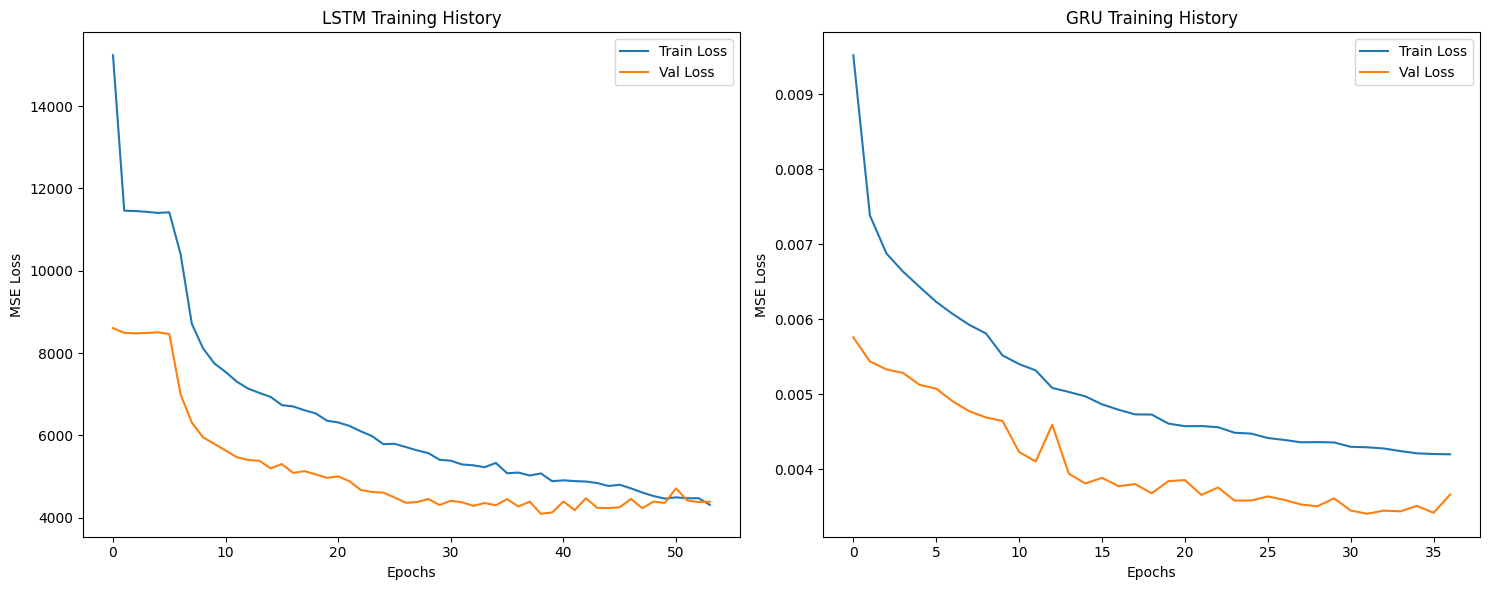

In [367]:
plt.figure(figsize=(15, 6))

# Plot LSTM Loss
plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['loss'], label='Train Loss')
plt.plot(lstm_history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training History')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()

# Plot GRU Loss
plt.subplot(1, 2, 2)
plt.plot(gru_history.history['loss'], label='Train Loss')
plt.plot(gru_history.history['val_loss'], label='Val Loss')
plt.title('GRU Training History')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()

plt.tight_layout()
plt.show()